In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.feature import hog
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler


In [2]:
TRAIN_PATH = "dataset/train"
TEST_PATH = "dataset/test"
categories = os.listdir(TRAIN_PATH)
for index, fruit in enumerate(categories):
    print(f"{index}  →  {fruit}")




0  →  apple
1  →  banana
2  →  grapes
3  →  kiwi
4  →  mango
5  →  orange
6  →  pear
7  →  pineapple
8  →  pomegranate
9  →  watermelon


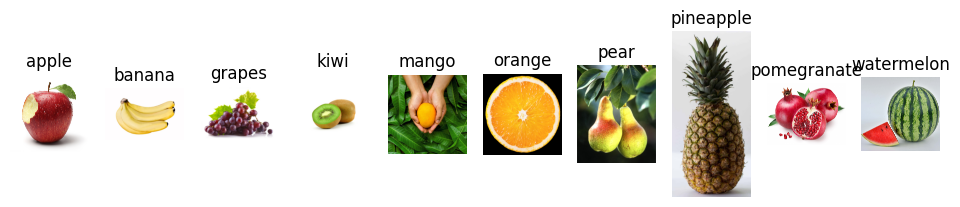

In [3]:
plt.figure(figsize=(12, 5))
for i, category in enumerate(categories):
    folder = os.path.join(TRAIN_PATH, category)
    img_name = os.listdir(folder)[0]
    img_path = os.path.join(folder, img_name)
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.subplot(1, len(categories), i+1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(category)

plt.show()


In [4]:
class_counts = {}
for folder in os.listdir(TRAIN_PATH):
    path = os.path.join(TRAIN_PATH, folder)
    files = os.listdir(path)
    print(folder, ":", len(files))
    class_counts[folder] = len(files)

print("TOTAL TRAIN IMAGES:", sum(class_counts.values()))


apple : 68
banana : 75
grapes : 100
kiwi : 88
mango : 86
orange : 69
pear : 89
pineapple : 99
pomegranate : 79
watermelon : 84
TOTAL TRAIN IMAGES: 837


In [5]:
X_train = []
y_train = []
for label, category in enumerate(categories):
    folder = os.path.join(TRAIN_PATH, category)
    for img_name in os.listdir(folder):
        path = os.path.join(folder, img_name)

        img = cv2.imread(path)
        hsv= cv2.cvtColor(img,cv2.COLOR_BGR2HSV)
        lower= np.array([0,40,40])
        upper= np.array([179,255,255])
        mask= cv2.inRange(hsv, lower,upper)
        img= cv2.bitwise_and(img,img,mask= mask)
        img = cv2.resize(img, (128,128))
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        hog_features = hog(gray, pixels_per_cell=(8,8), cells_per_block=(2,2))

        hist = cv2.calcHist([img], [0,1,2], None, [8,8,8],[0,256,0,256,0,256])
        hist = cv2.normalize(hist, hist).flatten()

        features = np.hstack((hog_features, hist))
        X_train.append(features)
        y_train.append(label)


X_train = np.array(X_train)
y_train = np.array(y_train)
scaler= StandardScaler()
X_train= scaler.fit_transform(X_train)
print("Train Shape:", X_train.shape, y_train.shape)


Train Shape: (837, 8612) (837,)


In [6]:
X_test = []
y_test = []
for label, category in enumerate(categories):
    folder = os.path.join(TEST_PATH, category)
    for img_name in os.listdir(folder):
        path = os.path.join(folder, img_name)

        img = cv2.imread(path)
        hsv= cv2.cvtColor(img,cv2.COLOR_BGR2HSV)
        lower= np.array([0,40,40])
        upper= np.array([179,255,255])
        mask= cv2.inRange(hsv, lower,upper)
        img= cv2.bitwise_and(img,img,mask= mask)
        
        img = cv2.resize(img, (128, 128))
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        hog_features = hog(gray, pixels_per_cell=(8,8), cells_per_block=(2,2))

        hist = cv2.calcHist([img], [0,1,2], None, [8,8,8],
                    [0,256,0,256,0,256])
        hist = cv2.normalize(hist, hist).flatten()

        features = np.hstack((hog_features, hist))
        X_test.append(features)
        y_test.append(label)

X_test = np.array(X_test)
X_test= scaler.transform(X_test)
y_test = np.array(y_test)
print("Test Shape:", X_test.shape, y_test.shape)


Test Shape: (99, 8612) (99,)


In [7]:
from sklearn.model_selection import GridSearchCV
param_grid = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']
}

grid = GridSearchCV(SVC(), param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid.fit(X_train, y_train)
print("Best Parameters:", grid.best_params_)
model = grid.best_estimator_


Best Parameters: {'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}


In [8]:
model.score(X_train, y_train)




1.0

In [9]:
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9797979797979798


In [10]:
import pandas as pd
df = pd.DataFrame({
    "Actual Label": y_test,
    "Predicted Label": y_pred
})
df.head(10)


,Actual Label,Predicted Label
0,0,0
1,0,0
2,0,0
3,0,0
4,0,1
5,0,8
6,0,0
7,0,0
8,0,0
9,0,0


In [11]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.80      0.89        10
           1       0.90      1.00      0.95         9
           2       1.00      1.00      1.00        10
           3       1.00      1.00      1.00        10
           4       1.00      1.00      1.00        10
           5       1.00      1.00      1.00        10
           6       1.00      1.00      1.00        10
           7       1.00      1.00      1.00        10
           8       0.91      1.00      0.95        10
           9       1.00      1.00      1.00        10

    accuracy                           0.98        99
   macro avg       0.98      0.98      0.98        99
weighted avg       0.98      0.98      0.98        99




Testing: apple.jpg


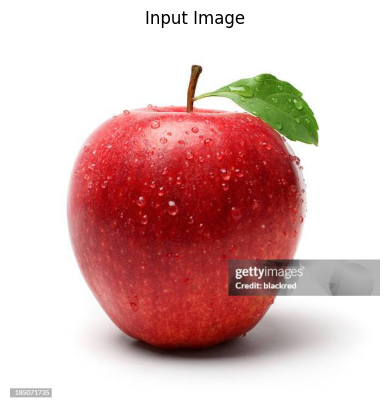

Predicted Class: apple

Testing: Banana.jpg


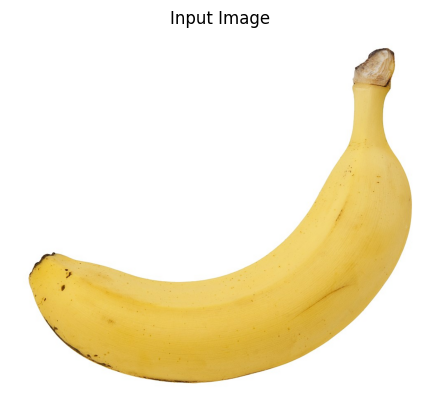

Predicted Class: banana

Testing: grape.jpg


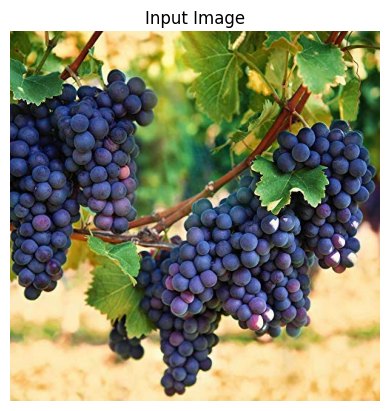

Predicted Class: grapes

Testing: kiwi.jpg


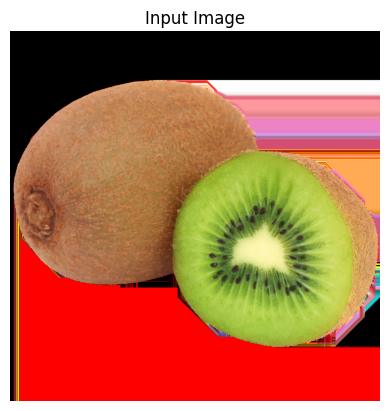

Predicted Class: kiwi

Testing: mango3.jpg


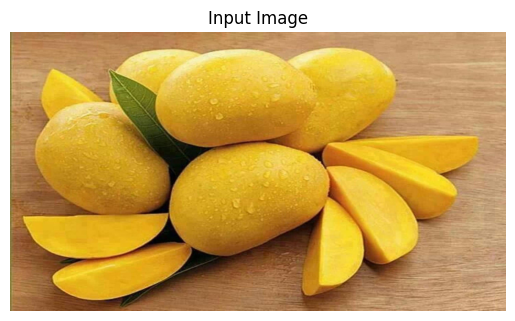

Predicted Class: mango

Testing: orange1.jpg


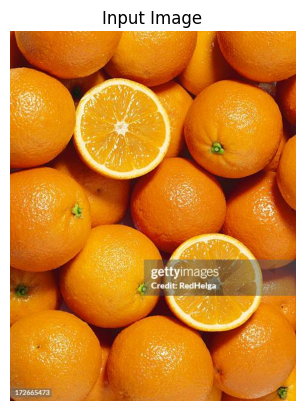

Predicted Class: orange

Testing: pear10.jpg


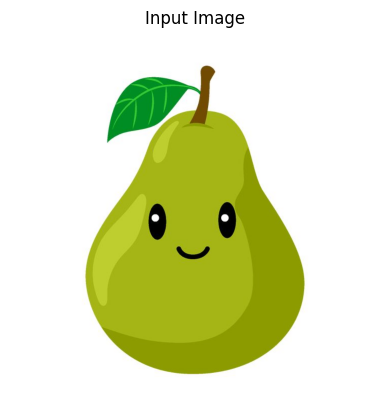

Predicted Class: pear

Testing: pineapple.jpg


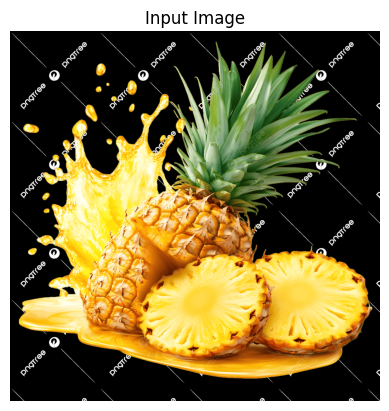

Predicted Class: pineapple

Testing: pomegranate.jpg


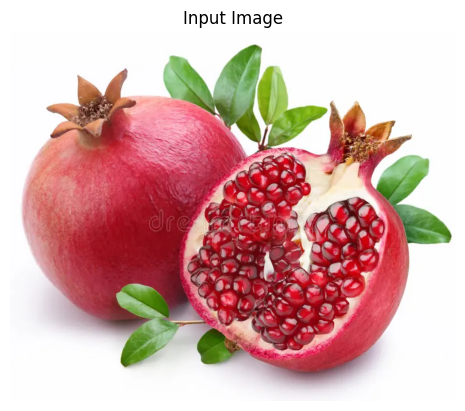

Predicted Class: pomegranate

Testing: watermelon1.jpg


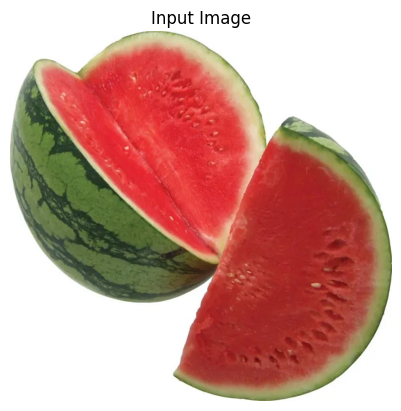

Predicted Class: watermelon


In [12]:

def predict_image(img_path):
    img = cv2.imread(img_path)

    if img is None:
        print("Image not found:", img_path)
        return None
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.title("Input Image")
    plt.show()

    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    lower = np.array([0, 40, 40])
    upper = np.array([179, 255, 255])
    mask = cv2.inRange(hsv, lower, upper)
    img = cv2.bitwise_and(img, img, mask=mask)
    
    img = cv2.resize(img, (128,128))
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    hog_features = hog(gray, pixels_per_cell=(8,8), cells_per_block=(2,2))

    hist = cv2.calcHist([img], [0,1,2], None, [8,8,8],
                        [0,256,0,256,0,256])
    hist = cv2.normalize(hist, hist).flatten()

    features = np.hstack((hog_features, hist)).reshape(1, -1)
    features = scaler.transform(features)

    pred = model.predict(features)
    predicted_class = categories[pred[0]]
    print("Predicted Class:", predicted_class)
    return predicted_class

test_images = [
    "apple.jpg",
    "Banana.jpg",
    "grape.jpg",
    "kiwi.jpg",
    "mango3.jpg",
    "orange1.jpg",
    "pear10.jpg",
    "pineapple.jpg",
    "pomegranate.jpg",
    "watermelon1.jpg"
]
for img_path in test_images:
    print("\nTesting:", img_path)
    predict_image(img_path)
